# Dataset description

In [1610]:
# Choose dataset to analyze
DATASET_NAME = "../data/3_unece_new_passenger car_registrations_by_fuel type_(detailed).csv"

In [1611]:
import pandas as pd

df = pd.read_csv(DATASET_NAME)

In [1612]:
df.head()

New passenger car registrations by fuel type (detailed)
Fuel Type Country 1993   1994   1995   1996   1997   1998   1999   2000   2001   2002   2003   2004   2005 2006   2007   2008   2009   2010   2011   2012   2013   2014   2015   2016   2017   2018   2019   2020   2021   2022   2023                                                 2024     
Total     Albania ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..   ..     ..     ..     ..     ..     6245   297370 ..     ..     ..     ..     ..     ..     42681  43661  58208  49459  66004                                               82931     
          Andorra ..     ..     2871   2744   3024   3340   3688   3717   3684   4295   4166   4286   ..   ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..                                                     ..     
          Armenia ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..   ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..     ..                                                     ..     
          Austria 285162 273663 279610 307671 275001 295865 314182 309427 293528 279493 300121 311292 ..   308594 298182 293697 319403 328563 356145 336010 319035 303318 308555 329604 353320 341068 329363 248740 239803 215050 239150                                             253789

In [1613]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 785 entries, ('Fuel Type', 'Country', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023') to ('- Others', 'Uzbekistan', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..', '..')
Data columns (total 1 columns):
 #   Column                                                   Non-Null Count  Dtype 
---  ------                                                   --------------  ----- 
 0   New passenger car registrations by fuel type (detailed)  785 non-null    object
dtypes: object(1)
memory usage: 353.1+ KB


### Convert the fuel hierarchy format to two columns: "Motor energy" and "Engine capacity of vehicle"

In [1614]:
import numpy as np

# From MultiIndex to a regular DataFrame
df = df.index.to_frame(index=False)
df.columns = df.iloc[0] # Use the first row as column names
df = df.iloc[1:].reset_index(drop=True) # Drop the first row and reset the index

# Convert from wide to long format
id_vars = ["Fuel Type", "Country"]
year_cols = [col for col in df.columns if str(col).isdigit()]
df = df.melt(
    id_vars=id_vars,
    value_vars=year_cols,
    var_name="TIME_PERIOD",
    value_name="OBS_VALUE",
)

# Rename columns to match Eurostat ones
df.rename(
    columns={
        "Fuel Type": "Motor energy",
        "Country": "Geopolitical entity (reporting)"
    },
    inplace=True,
)

# Convert OBS_VALUE to numeric, replacing ".." with NaN
df["OBS_VALUE"] = (
    df["OBS_VALUE"]
    .replace("..", np.nan)
    .astype(float)
)

# Convert TIME_PERIOD to int
df["TIME_PERIOD"] = df["TIME_PERIOD"].astype(int)


# Convert from fuel hierarchy to two columns: "Motor energy" and "Engine capacity of vehicle"
fuel_rows = []
fuel_type = None

for value in df["Motor energy"]:

    if value == "Total":
        fuel_type = "Total"
        engine_capacity = "Total"

    elif "Petrol" in value:
        fuel_type = "Petrol"
        engine_capacity = "Total"

    elif "Diesel" in value:
        fuel_type = "Diesel"
        engine_capacity = "Total"

    elif "Alternative" in value:
        # Do not keep the parent category
        fuel_type = None
        engine_capacity = None

    elif value.startswith("-"):
        detail = value.replace("-", "").strip()

        if detail in ["Electricity", "LPG", "Natural gas", "Others"]:
            fuel_type = detail
            engine_capacity = "Total"
        else:
            engine_capacity = detail

    fuel_rows.append((fuel_type, engine_capacity))

df.drop(columns=["Motor energy"], inplace=True)
df[["Motor energy", "Engine capacity of vehicle"]] = fuel_rows
df = df[df["Motor energy"].notna()].copy() # Drop rows where "Motor energy" is None

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22568 entries, 0 to 24303
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Geopolitical entity (reporting)  22568 non-null  object 
 1   TIME_PERIOD                      22568 non-null  int32  
 2   OBS_VALUE                        8443 non-null   float64
 3   Motor energy                     22568 non-null  object 
 4   Engine capacity of vehicle       22568 non-null  object 
dtypes: float64(1), int32(1), object(3)
memory usage: 969.7+ KB


### Add 'geo' column to match Eurostat dataset

In [1615]:
import country_converter as coco

# Add ISO2 country code columns 'geo'
df["geo"] = coco.convert(
    names=df["Geopolitical entity (reporting)"],
    to="ISO2",
    not_found="Unknown"
)

# Change columns order to match Eurostat dataset
df = df[
    [
        "Motor energy",
        "Engine capacity of vehicle",
        "geo",
        "Geopolitical entity (reporting)",
        "TIME_PERIOD",
        "OBS_VALUE"
    ]
]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22568 entries, 0 to 24303
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Motor energy                     22568 non-null  object 
 1   Engine capacity of vehicle       22568 non-null  object 
 2   geo                              22568 non-null  object 
 3   Geopolitical entity (reporting)  22568 non-null  object 
 4   TIME_PERIOD                      22568 non-null  int32  
 5   OBS_VALUE                        8443 non-null   float64
dtypes: float64(1), int32(1), object(4)
memory usage: 1.1+ MB


In [1616]:
for col in df.columns:
    print(f"Column {col}: {df[col].unique()}")

Column Motor energy: ['Total' 'Petrol' 'Diesel' 'Electricity' 'LPG' 'Natural gas' 'Others']
Column Engine capacity of vehicle: ['Total' 'Up to 1399cc' '1400cc  1999cc' '2000cc and more']
Column geo: ['AL' 'AD' 'AM' 'AT' 'AZ' 'BY' 'BE' 'BA' 'BG' 'CA' 'HR' 'CY' 'CZ' 'DK'
 'EE' 'FI' 'FR' 'GE' 'DE' 'GR' 'HU' 'IS' 'IE' 'IL' 'IT' 'KZ' 'KG' 'LV'
 'LI' 'LT' 'LU' 'MT' 'MC' 'ME' 'NL' 'MK' 'NO' 'PL' 'PT' 'MD' 'RO' 'RU'
 'SM' 'RS' 'SK' 'SI' 'ES' 'SE' 'CH' 'TJ' 'TR' 'TM' 'UA' 'GB' 'US' 'UZ']
Column Geopolitical entity (reporting): ['Albania' 'Andorra' 'Armenia' 'Austria' 'Azerbaijan' 'Belarus' 'Belgium'
 'Bosnia and Herzegovina' 'Bulgaria' 'Canada' 'Croatia' 'Cyprus' 'Czechia'
 'Denmark' 'Estonia' 'Finland' 'France' 'Georgia' 'Germany' 'Greece'
 'Hungary' 'Iceland' 'Ireland' 'Israel' 'Italy' 'Kazakhstan' 'Kyrgyzstan'
 'Latvia' 'Liechtenstein' 'Lithuania' 'Luxembourg' 'Malta' 'Monaco'
 'Montenegro' 'Netherlands' 'North Macedonia' 'Norway' 'Poland' 'Portugal'
 'Republic of Moldova' 'Romania' 'Russian

In [1617]:
df["TIME_PERIOD"].min(), df["TIME_PERIOD"].max()

(1993, 2023)

In [1618]:
df["geo"].nunique(), df["Geopolitical entity (reporting)"].unique()

(56,
 array(['Albania', 'Andorra', 'Armenia', 'Austria', 'Azerbaijan',
        'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria',
        'Canada', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia',
        'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Hungary',
        'Iceland', 'Ireland', 'Israel', 'Italy', 'Kazakhstan',
        'Kyrgyzstan', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg',
        'Malta', 'Monaco', 'Montenegro', 'Netherlands', 'North Macedonia',
        'Norway', 'Poland', 'Portugal', 'Republic of Moldova', 'Romania',
        'Russian Federation', 'San Marino', 'Serbia', 'Slovakia',
        'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Tajikistan',
        'Turkiye', 'Turkmenistan', 'Ukraine', 'United Kingdom',
        'United States', 'Uzbekistan'], dtype=object))

### Map 'geo' countries to continent

In [1619]:
import country_converter as coco

df_continent = pd.DataFrame({
    "geo": df["geo"].drop_duplicates()
})

df_continent = df_continent[df_continent["geo"] != "EU27_2020"]

df_continent["continent"] = coco.convert(
    names=df_continent["geo"],
    to="continent",
    not_found="Unknown"
)

# Count the number of countries per continent
df_continent.groupby("continent").size().reset_index(name="count")

,continent,count
0,America,2
1,Asia,11
2,Europe,43


# Data inspection, cleaning and preprocessing

In [1620]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22568 entries, 0 to 24303
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Motor energy                     22568 non-null  object 
 1   Engine capacity of vehicle       22568 non-null  object 
 2   geo                              22568 non-null  object 
 3   Geopolitical entity (reporting)  22568 non-null  object 
 4   TIME_PERIOD                      22568 non-null  int32  
 5   OBS_VALUE                        8443 non-null   float64
dtypes: float64(1), int32(1), object(4)
memory usage: 1.1+ MB


In [1621]:
df['OBS_VALUE'].min(), df['OBS_VALUE'].max()

(0.0, 8903064.0)

In [1622]:
df['TIME_PERIOD'].sort_values().unique()

array([1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [1623]:
for col in df.columns:
    print(f"Column {col}: {df[col].unique()}")

Column Motor energy: ['Total' 'Petrol' 'Diesel' 'Electricity' 'LPG' 'Natural gas' 'Others']
Column Engine capacity of vehicle: ['Total' 'Up to 1399cc' '1400cc  1999cc' '2000cc and more']
Column geo: ['AL' 'AD' 'AM' 'AT' 'AZ' 'BY' 'BE' 'BA' 'BG' 'CA' 'HR' 'CY' 'CZ' 'DK'
 'EE' 'FI' 'FR' 'GE' 'DE' 'GR' 'HU' 'IS' 'IE' 'IL' 'IT' 'KZ' 'KG' 'LV'
 'LI' 'LT' 'LU' 'MT' 'MC' 'ME' 'NL' 'MK' 'NO' 'PL' 'PT' 'MD' 'RO' 'RU'
 'SM' 'RS' 'SK' 'SI' 'ES' 'SE' 'CH' 'TJ' 'TR' 'TM' 'UA' 'GB' 'US' 'UZ']
Column Geopolitical entity (reporting): ['Albania' 'Andorra' 'Armenia' 'Austria' 'Azerbaijan' 'Belarus' 'Belgium'
 'Bosnia and Herzegovina' 'Bulgaria' 'Canada' 'Croatia' 'Cyprus' 'Czechia'
 'Denmark' 'Estonia' 'Finland' 'France' 'Georgia' 'Germany' 'Greece'
 'Hungary' 'Iceland' 'Ireland' 'Israel' 'Italy' 'Kazakhstan' 'Kyrgyzstan'
 'Latvia' 'Liechtenstein' 'Lithuania' 'Luxembourg' 'Malta' 'Monaco'
 'Montenegro' 'Netherlands' 'North Macedonia' 'Norway' 'Poland' 'Portugal'
 'Republic of Moldova' 'Romania' 'Russian

### Zeros observations

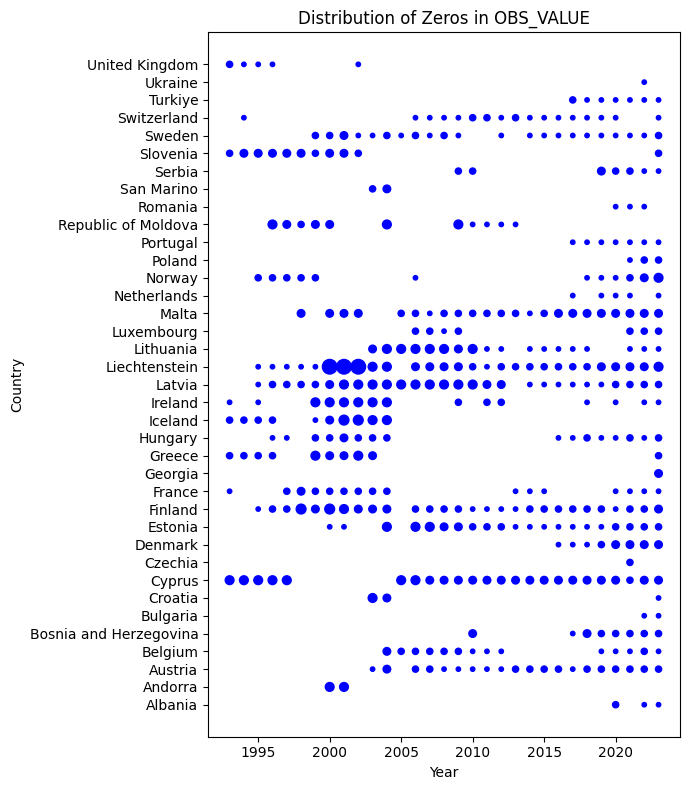

In [1624]:
import matplotlib.pyplot as plt

zeros = df[df["OBS_VALUE"] == 0]
zero_counts = (
    zeros.groupby(["Geopolitical entity (reporting)", "TIME_PERIOD"])
    .size()
    .reset_index(name="zero_count")
)
zero_counts["Geopolitical entity (reporting)"] = zero_counts["Geopolitical entity (reporting)"].replace("Kosovo*", "Kosovo")

plt.figure(figsize=(7, 8))

plt.scatter(
    zero_counts["TIME_PERIOD"],
    zero_counts["Geopolitical entity (reporting)"],
    s=zero_counts["zero_count"] * 10,  # bubble size * 10 to improve visibility
    color="blue"
)

plt.xlabel("Year")
plt.ylabel("Country")
plt.title("Distribution of Zeros in OBS_VALUE")

plt.tight_layout()
plt.savefig("img/zeros_distrib_in_OBS_VALUE.png", dpi=300)
plt.show()

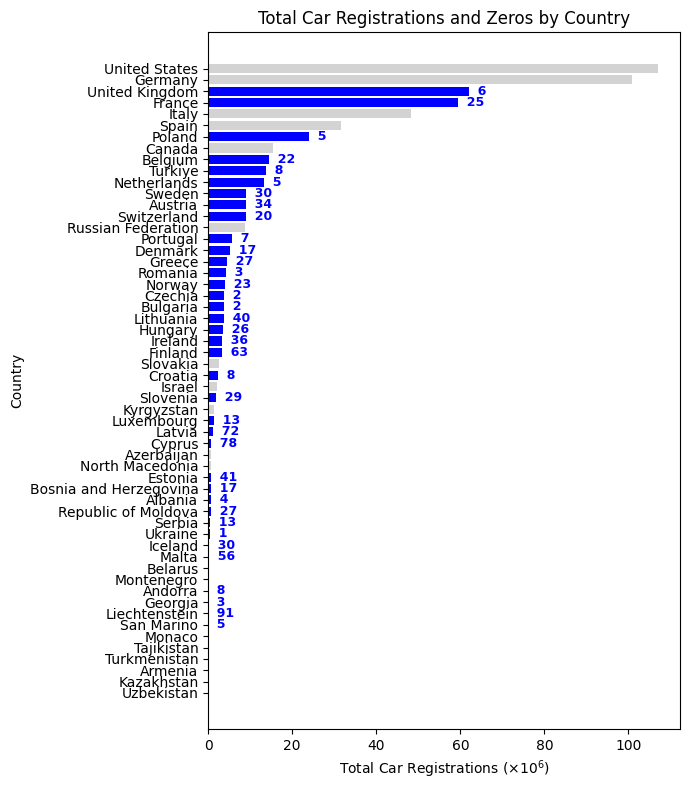

In [1625]:
import matplotlib.pyplot as plt

total_registrations_per_country = (
    df[df["Motor energy"] == "Total"]
    .groupby("Geopolitical entity (reporting)")["OBS_VALUE"]
    .sum()
)
zero_observations_per_country = (
    df[df["OBS_VALUE"] == 0]
    .groupby("Geopolitical entity (reporting)")
    .size()
)

# [total_registrations, zero_observations]
plot_df = pd.DataFrame({
    "total_registrations": total_registrations_per_country,
    "zero_observations": zero_observations_per_country
}).fillna(0)
plot_df.rename(
    index={"Kosovo*": "Kosovo"},
    inplace=True
)
plot_df = plot_df.drop(
    index="European Union - 27 countries (from 2020)",
    errors="ignore"
)
plot_df = plot_df.sort_values("total_registrations")


fig, ax = plt.subplots(figsize=(7, 8))

# Blue bars for countries with zero observations, light gray for others
bar_colors = [
    "blue" if z > 0 else "lightgray"
    for z in plot_df["zero_observations"]
]

ax.barh(
    plot_df.index,
    plot_df["total_registrations"] / 1e6,
    color=bar_colors
)

# Labels for countries with zero observations
for country, registrations, zeros in zip(
    plot_df.index,
    plot_df["total_registrations"] / 1e6,
    plot_df["zero_observations"]
):
    if zeros > 0:
        ax.text(
            registrations,
            country,
            f"  {int(zeros)}",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="blue"
        )

ax.set_xlabel("Total Car Registrations ($\\times10^6$)")
ax.set_ylabel("Country")

ax.set_title("Total Car Registrations and Zeros by Country")

plt.tight_layout()
plt.savefig("img/total_car_registrations_and_zeros_by_country.png", dpi=300)
plt.show()

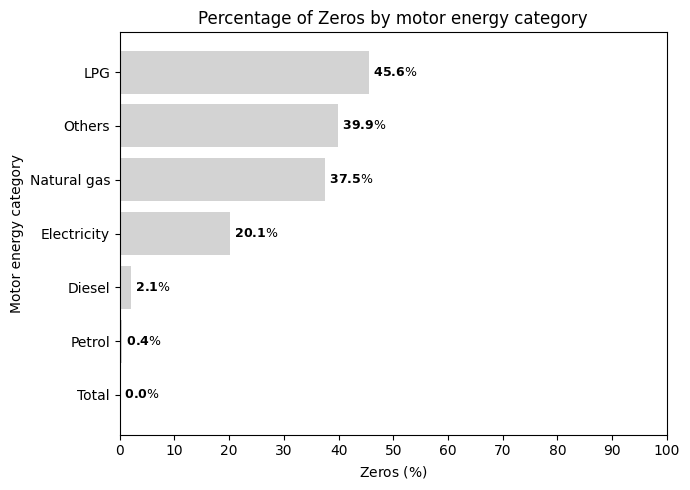

In [1626]:
import matplotlib.pyplot as plt

# [total_observations, zero_observations]
plot_df = (
    df.groupby("Motor energy")["OBS_VALUE"]
    .agg(
        total_observations="count",
        zero_observations=lambda x: (x == 0).sum()
    )
)

# [total_observations, zero_observations, zero_percentage]
plot_df["zero_percentage"] = (
    plot_df["zero_observations"] /
    plot_df["total_observations"] * 100
)

plot_df.sort_values("zero_percentage", inplace=True)

plt.figure(figsize=(7, 5))

plt.barh(
    plot_df.index,
    plot_df["zero_percentage"],
    color="lightgrey"
)

# Add percentage labels
for category, value in zip(plot_df.index, plot_df["zero_percentage"]):
    # To avoid overlapping with the plot borders
    # If value is > 85, put it inside the bar
    if value > 85:
        plt.text(
            value - 0.5,
            category,
            f"{value:.1f}$\%$",
            va="center",
            ha="right",
            fontsize=9,
            fontweight="bold",
            color="black"
        )
    # Otherwise put it outside the bar
    else:
        plt.text(
            value,
            category,
            f" {value:.1f}$\%$",
            va="center",
            ha="left",
            fontsize=9,
            fontweight="bold"
        )

plt.xlim(0, 100)
plt.xticks(range(0, 101, 10))

plt.xlabel("Zeros ($\%$)")
plt.ylabel("Motor energy category")
plt.title("Percentage of Zeros by motor energy category")

plt.tight_layout()
plt.savefig("img/percentage_of_zeros_by_motor_energy_category.png", dpi=300)
plt.show()

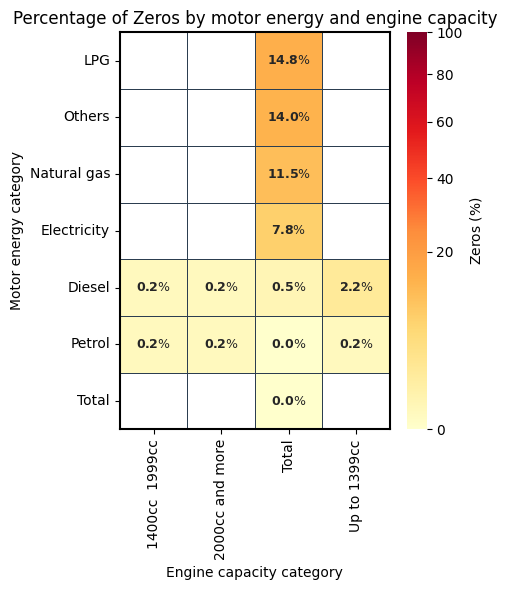

In [1627]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns

# Get the percentage of zeros by motor energy and engine capacity
df_zero = df.assign(is_zero=(df["OBS_VALUE"] == 0) * 100)
zero_heatmap = (
    df_zero.groupby(["Motor energy", "Engine capacity of vehicle"])["is_zero"]
    .mean()
    .unstack()
)
zero_heatmap = zero_heatmap.loc[zero_heatmap.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(5, 6))

annot_labels = zero_heatmap.map(lambda x: f"{x:.1f}$\%$")
ax = sns.heatmap(
    zero_heatmap,
    annot=annot_labels,
    fmt="",
    annot_kws={"weight": "bold", "size": 9},
    cmap="YlOrRd",
    norm=mcolors.PowerNorm(gamma=0.5, vmin=0, vmax=100),
    linewidths=0.5,
    linecolor="#2c3e50",
    cbar_kws={"label": "Zeros ($\%$)"},
)

for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

plt.xlabel("Engine capacity category")
plt.ylabel("Motor energy category")
plt.title("Percentage of Zeros by motor energy and engine capacity")

plt.tight_layout()
plt.savefig("img/percentage_of_zeros_by_motor_energy_and_engine_capacity.png", dpi=300)
plt.show()


### NaN observations for the "OBS_VALUE" column

In [1628]:
# Check for NaN values in the OBS_VALUE column
nan_obs_value = df[df["OBS_VALUE"].isna()]

display(nan_obs_value)


,Motor energy,Engine capacity of vehicle,geo,Geopolitical entity (reporting),TIME_PERIOD,OBS_VALUE
0,Total,Total,AL,Albania,1993,NaN
1,Total,Total,AD,Andorra,1993,NaN
2,Total,Total,AM,Armenia,1993,NaN
4,Total,Total,AZ,Azerbaijan,1993,NaN
7,Total,Total,BA,Bosnia and Herzegovina,1993,NaN
...,...,...,...,...,...,...
24290,Others,Total,SM,San Marino,2023,NaN
24297,Others,Total,TJ,Tajikistan,2023,NaN
24299,Others,Total,TM,Turkmenistan,2023,NaN
24302,Others,Total,US,United States,2023,NaN


### Try to find a pattern for the NaN values in the "OBS_VALUE" column

It seems there is no clear pattern, since the NaN values are scattered across different years, countries, and fuel types. 

In [1629]:
# Percentage of missing values by motor energy
df["OBS_VALUE"].isna().groupby(df["Motor energy"]).mean().sort_values(ascending=False) * 100

Motor energy
Natural gas    69.239631
LPG            67.569124
Others         64.919355
Petrol         64.573733
Diesel         64.516129
Electricity    61.117512
Total          34.447005
Name: OBS_VALUE, dtype: float64

In [1630]:
# Percentage of missing values by engine category
df["OBS_VALUE"].isna().groupby(df["Engine capacity of vehicle"]).mean().sort_values(ascending=False) * 100

Engine capacity of vehicle
Up to 1399cc       68.836406
2000cc and more    68.634793
1400cc  1999cc     68.548387
Total              57.373272
Name: OBS_VALUE, dtype: float64

In [1631]:
# Count the number of unique countries with NaN values in the OBS_VALUE column
df[df["OBS_VALUE"].isna()]["geo"].nunique()

56

In [1632]:
# Count the number of NaN values in the OBS_VALUE column by TIME_PERIOD
df[df["OBS_VALUE"].isna()].groupby("TIME_PERIOD").size()

TIME_PERIOD
1993    640
1994    643
1995    619
1996    605
1997    598
1998    588
1999    561
2000    520
2001    523
2002    521
2003    516
2004    479
2005    557
2006    471
2007    455
2008    449
2009    420
2010    400
2011    417
2012    418
2013    420
2014    408
2015    403
2016    380
2017    349
2018    347
2019    301
2020    301
2021    267
2022    277
2023    272
dtype: int64

### Drop non EU27_2020 countries

In [1633]:
eu27_2020 = ['BE', 'BG', 'CZ', 'DK', 'DE', 'EE', 'IE', 'EL', 'ES', 'FR', 'HR', 'IT', 'CY', 'LV', 'LT', 'LU', 'HU', 'MT', 'NL', 'AT', 'PL', 'PT', 'RO', 'SI', 'SK', 'FI', 'SE']

# Check wether the df contains all the EU27_2020 countries
df_countries = df["geo"].unique().tolist()
all_countries_in_df = all(country in df_countries for country in eu27_2020)

print(all_countries_in_df) # True, all EU27_2020 countries are present in the dataset

False


In [1634]:
# Filter the dataset to include only EU27_2020 countries
df = df[df["geo"].isin(eu27_2020)]

print(df["geo"].nunique()) # 27, only EU27_2020 countries are present in the dataset

26


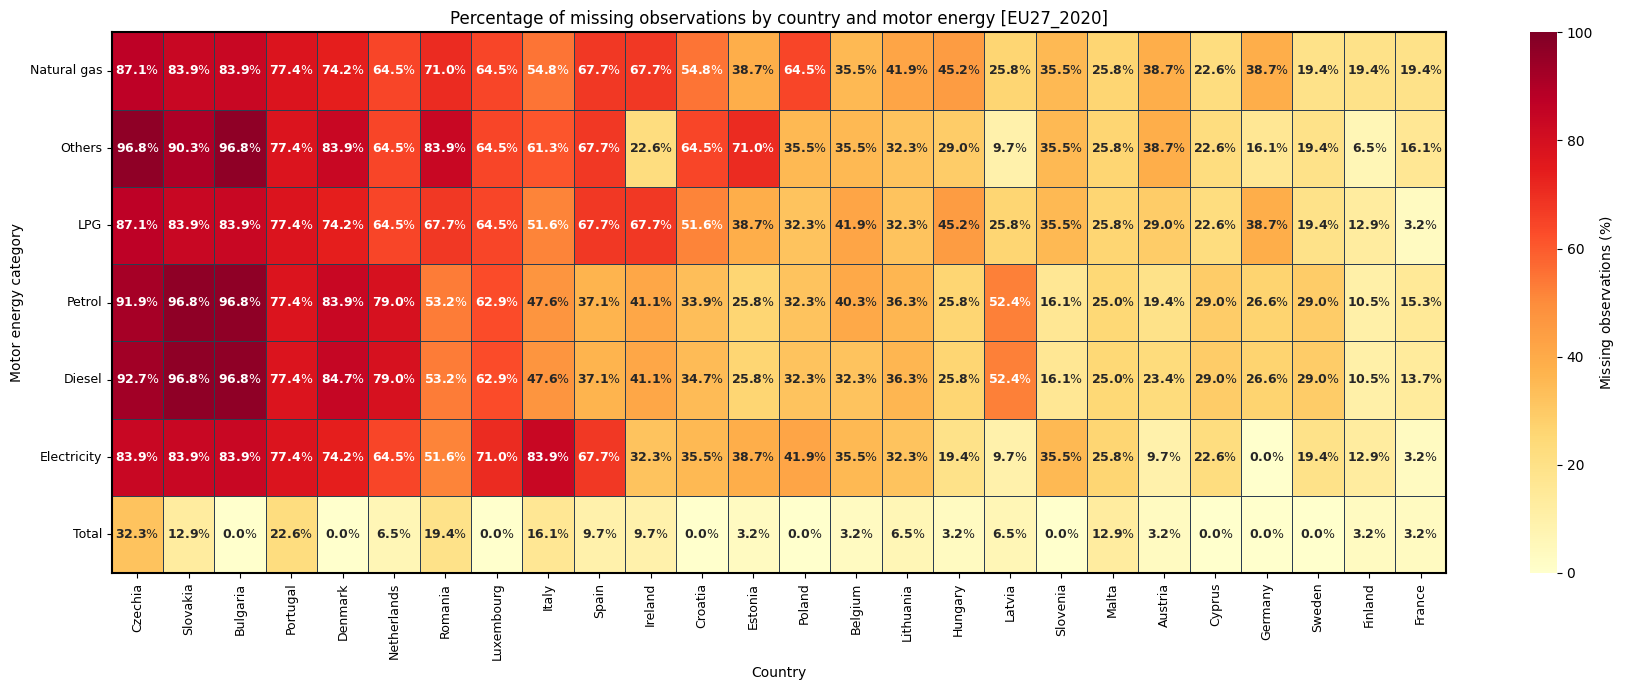

In [1635]:
import matplotlib.pyplot as plt
import seaborn as sns

missing_heatmap = (
    df.assign(is_missing=df["OBS_VALUE"].isna())
    .groupby(["Motor energy", "Geopolitical entity (reporting)"])["is_missing"]
    .mean()
    .unstack()
    * 100
)

# Sort the heatmap by the mean of missing values across countries and motor energy categories
missing_heatmap = missing_heatmap[missing_heatmap.mean(axis=0).sort_values(ascending=False).index]
missing_heatmap = missing_heatmap.loc[missing_heatmap.mean(axis=1).sort_values(ascending=False).index]


plt.figure(figsize=(18, 7))
annot_labels = missing_heatmap.map(lambda x: f"{x:.1f}$\%$")
ax = sns.heatmap(
    missing_heatmap,
    annot=annot_labels,
    fmt="",
    annot_kws={"weight": "bold", "size": 9},
    cmap="YlOrRd",
    vmin=0, vmax=100,
    linewidths=0.5,
    linecolor="#2c3e50",
    cbar_kws={"label": "Missing observations ($\%$)"},
)

# Heatmap border
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

plt.xlabel("Country")
plt.ylabel("Motor energy category")
plt.title("Percentage of missing observations by country and motor energy [EU27_2020]")
plt.xticks(rotation=90, ha="center", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("img/percentage_of_missing_by_country_and_motor_energy.png", dpi=300)
plt.show()


In [1636]:
df.to_csv('../data/cleaned/3c_unece_new_passenger car_registrations_by_fuel type_(detailed).csv', index=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10478 entries, 3 to 24295
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Motor energy                     10478 non-null  object 
 1   Engine capacity of vehicle       10478 non-null  object 
 2   geo                              10478 non-null  object 
 3   Geopolitical entity (reporting)  10478 non-null  object 
 4   TIME_PERIOD                      10478 non-null  int32  
 5   OBS_VALUE                        5953 non-null   float64
dtypes: float64(1), int32(1), object(4)
memory usage: 532.1+ KB
